In [1]:
import pandas as pd 

COLNAMES = {
    'loggingTime.txt.': 'timestamp',
    'motionUserAccelerationX.G.': 'acc_x',
    'motionUserAccelerationY.G.': 'acc_y',
    'motionUserAccelerationZ.G.': 'acc_z',
}

COLNAMES_WITH_GYRO = {
    'loggingTime.txt.': 'timestamp',
    'motionUserAccelerationX.G.': 'acc_x',
    'motionUserAccelerationY.G.': 'acc_y',
    'motionUserAccelerationZ.G.': 'acc_z',
    "motionRotationRateX.rad.s.": "gyro_x",
    "motionRotationRateY.rad.s.": "gyro_y",
    "motionRotationRateZ.rad.s.": "gyro_z"
}

def parse_csv_data(path, save_gyro = False):
    df = pd.read_csv(path)

    # keep only the desired cols
    # rename the columns for simplicity
    if save_gyro:
        df = df[COLNAMES_WITH_GYRO.keys()]
        df.rename(columns=COLNAMES_WITH_GYRO, inplace=True)
    else:
        df = df[COLNAMES.keys()]
        df.rename(columns=COLNAMES, inplace=True)


    # transforms the timestamp into ms from first timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df['timestamp'] = round(df['timestamp'].astype('int64') / 1e6)

    first_timestamp = df['timestamp'].iloc[0]
    df['timestamp'] = df['timestamp'] - first_timestamp


    return df

In [4]:
import os
import time

raw_data_path = '../data/kaggle-drdataboston/subjects'

parsed_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data'

time_start = time.perf_counter()
idx = 0
files_to_parse = [f for f in os.listdir(raw_data_path) if (os.path.isfile(os.path.join(raw_data_path, f)) and os.path.splitext(os.path.join(raw_data_path, f))[1] == '.csv')]

nr_files_to_parse = len(files_to_parse)
for filename in files_to_parse:

    full_path = os.path.join(raw_data_path, filename)
    
    if idx % 5 == 0:
        print(f"Processed {idx}/{nr_files_to_parse} files")
        current_time = time.perf_counter()
        print(f"Elapsed: {current_time - time_start:.6f} s")

    idx += 1
    csv_data = parse_csv_data(full_path)
    
    csv_data.to_csv(os.path.join(parsed_data_path, filename), index=False)

time_end = time.perf_counter()
print("All done!")
print(f"Total: {time_end - time_start:.6f} s")


Processed 0/272 files
Elapsed: 0.005656 s
Processed 5/272 files
Elapsed: 3.740206 s
Processed 10/272 files
Elapsed: 7.239070 s
Processed 15/272 files
Elapsed: 11.056725 s
Processed 20/272 files
Elapsed: 14.729038 s
Processed 25/272 files
Elapsed: 18.673786 s
Processed 30/272 files
Elapsed: 22.778255 s
Processed 35/272 files
Elapsed: 26.305790 s
Processed 40/272 files
Elapsed: 30.106505 s
Processed 45/272 files
Elapsed: 33.797617 s
Processed 50/272 files
Elapsed: 37.488681 s
Processed 55/272 files
Elapsed: 41.039476 s
Processed 60/272 files
Elapsed: 44.405013 s
Processed 65/272 files
Elapsed: 47.880086 s
Processed 70/272 files
Elapsed: 52.991682 s
Processed 75/272 files
Elapsed: 56.941622 s
Processed 80/272 files
Elapsed: 61.189494 s
Processed 85/272 files
Elapsed: 65.651188 s
Processed 90/272 files
Elapsed: 69.322453 s
Processed 95/272 files
Elapsed: 72.650067 s
Processed 100/272 files
Elapsed: 76.338743 s
Processed 105/272 files
Elapsed: 80.424905 s
Processed 110/272 files
Elapsed: 84

Presenting the first 5 resulting gyroscope data

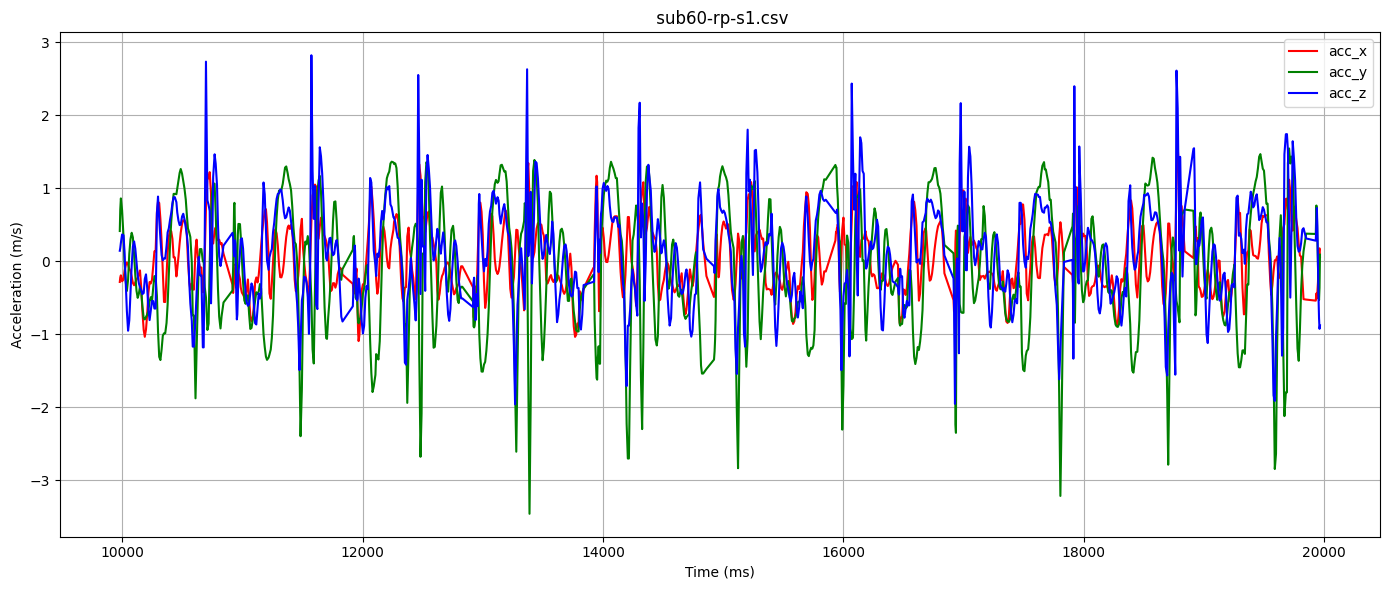

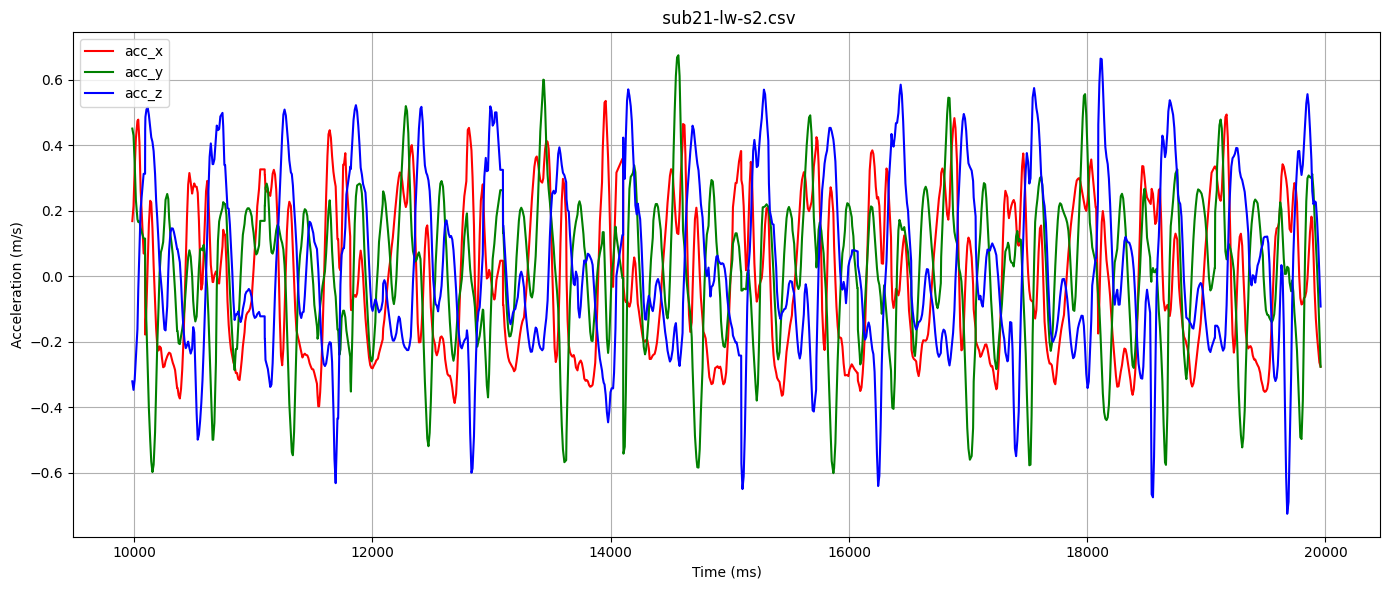

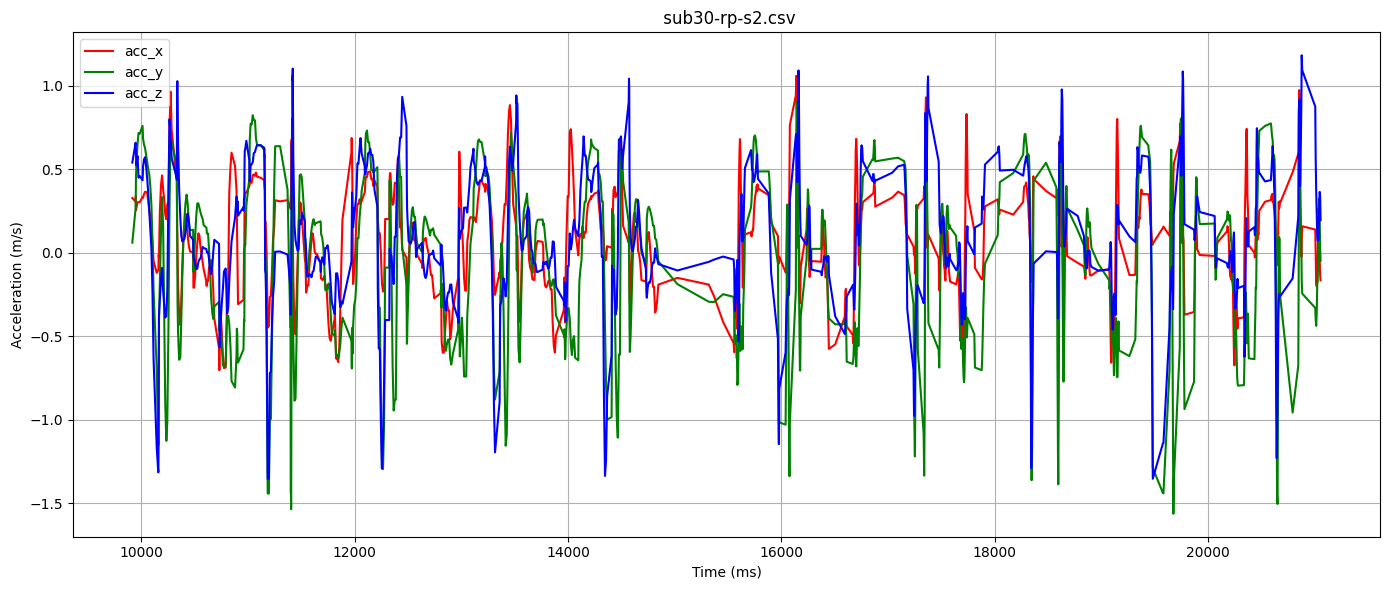

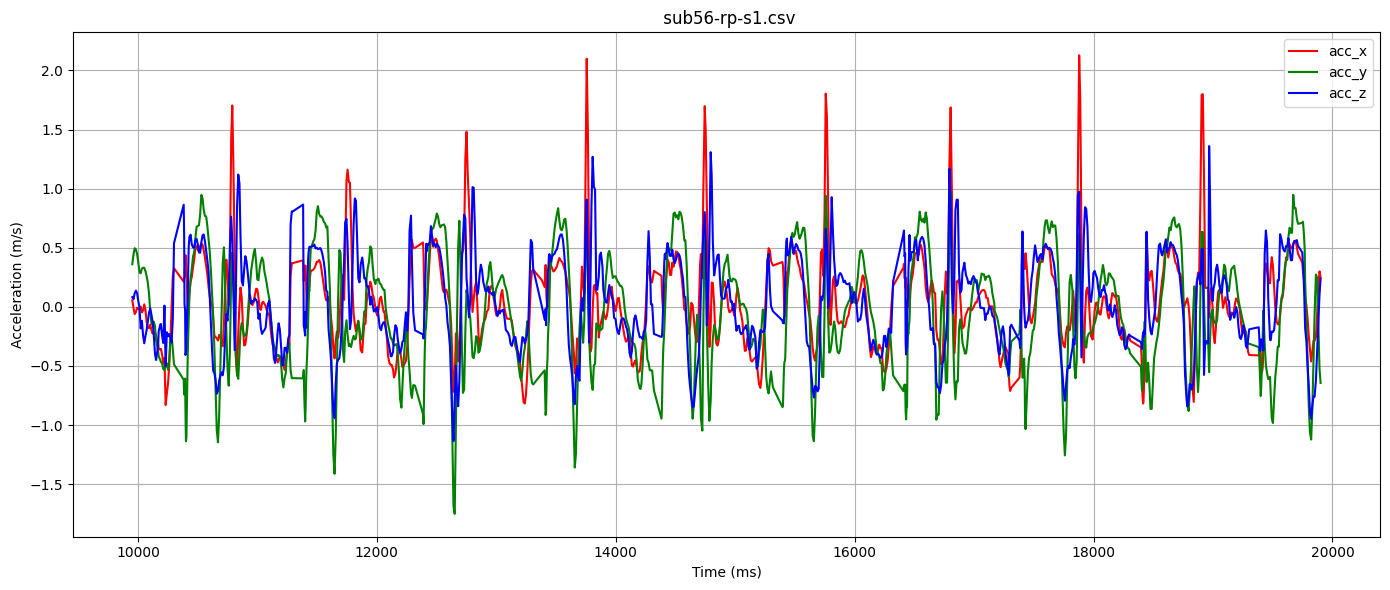

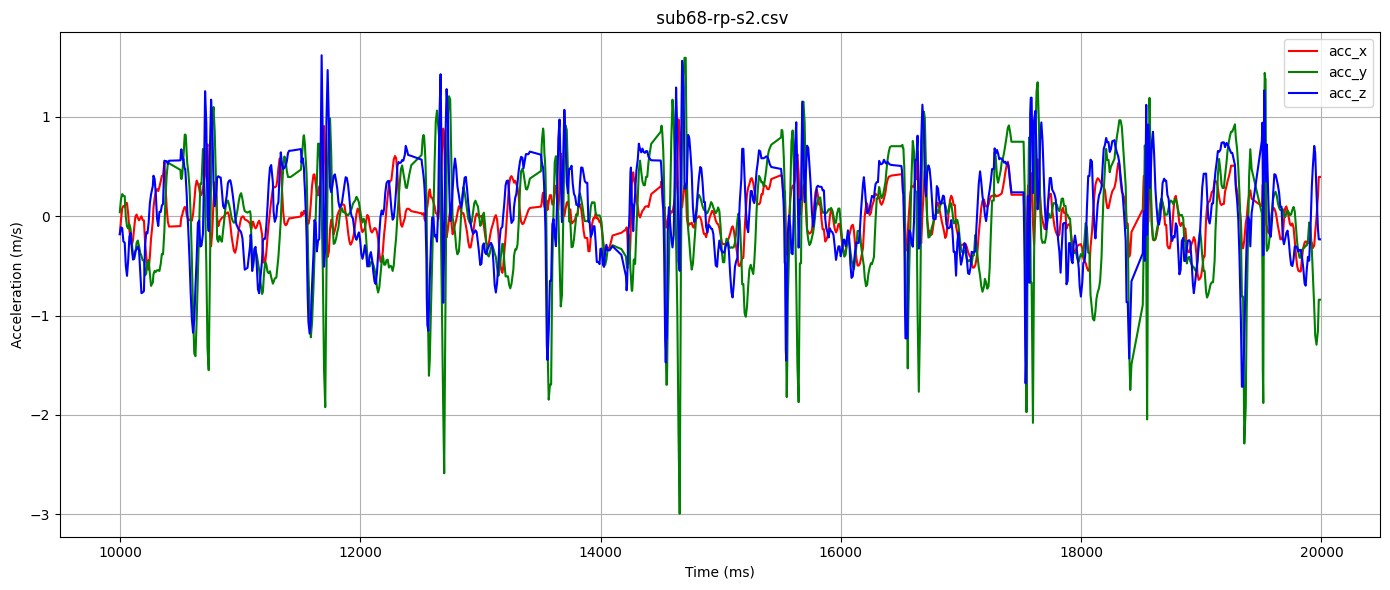

In [ ]:
import matplotlib.pyplot as plt 

parsed_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data'

files_to_print = [f for f in os.listdir(parsed_data_path) if (os.path.isfile(os.path.join(parsed_data_path, f)) and os.path.splitext(os.path.join(parsed_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[5:10]
COLORS = {
    'acc_x': 'r',
    'acc_y': 'g',
    'acc_z': 'b'
}

for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(parsed_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    

    for axis in ['acc_x', 'acc_y', 'acc_z']:
        plt.plot(csv_data['timestamp'], csv_data[axis], label=f'{axis}', color=COLORS[axis])

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


https://arxiv.org/pdf/1801.02336

We will perform the operations presented in the paper on part 1 data collection 

1. Computing average magnitude

In [ ]:


files_to_print = [f for f in os.listdir(parsed_data_path) if (os.path.isfile(os.path.join(parsed_data_path, f)) and os.path.splitext(os.path.join(parsed_data_path, f))[1] == '.csv')]

files_to_modify = files_to_print

mag_reduced_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data_mag_reduced'

import numpy as np

for filename in files_to_modify:
    csv_data = pd.read_csv(os.path.join(parsed_data_path, filename)) 

    csv_data['magnitude'] = np.sqrt(csv_data['acc_x']**2 + csv_data['acc_y']**2 + csv_data['acc_z']**2)

    avg_magnitude = csv_data['magnitude'].mean()

    csv_data['magnitude'] = csv_data['magnitude'] - avg_magnitude

    csv_data = csv_data.drop(['acc_x', 'acc_y', 'acc_z'], axis=1)

    csv_data.to_csv(os.path.join(mag_reduced_data_path, filename), index=False)

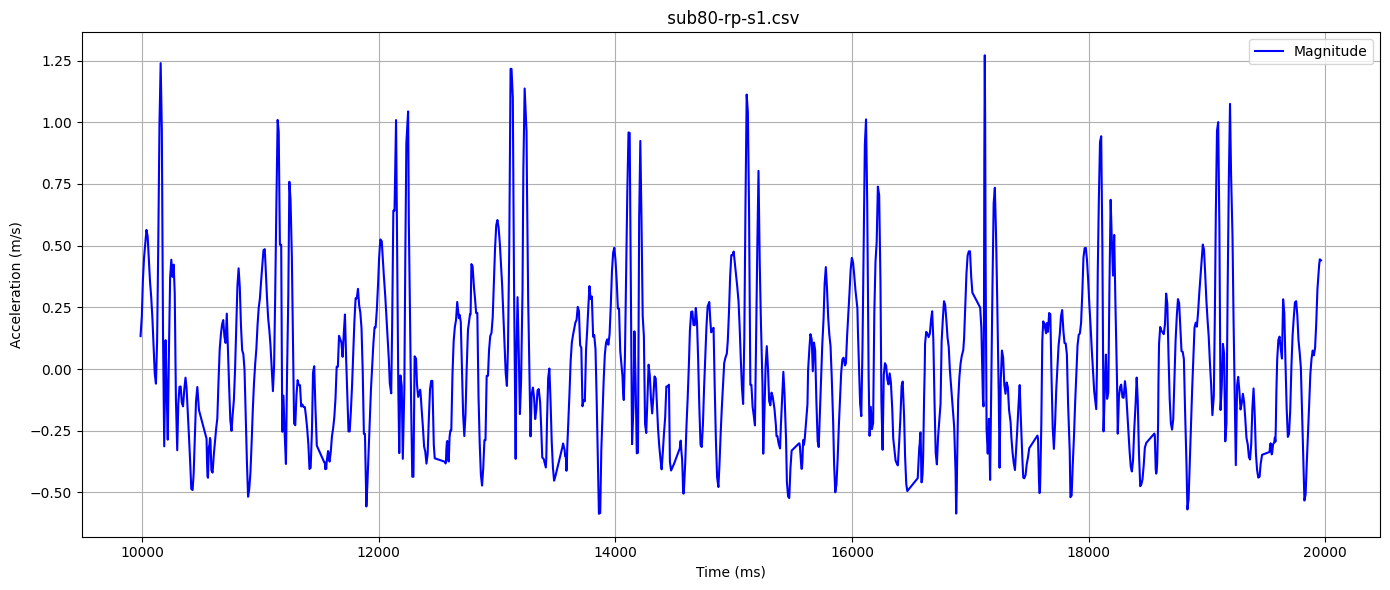

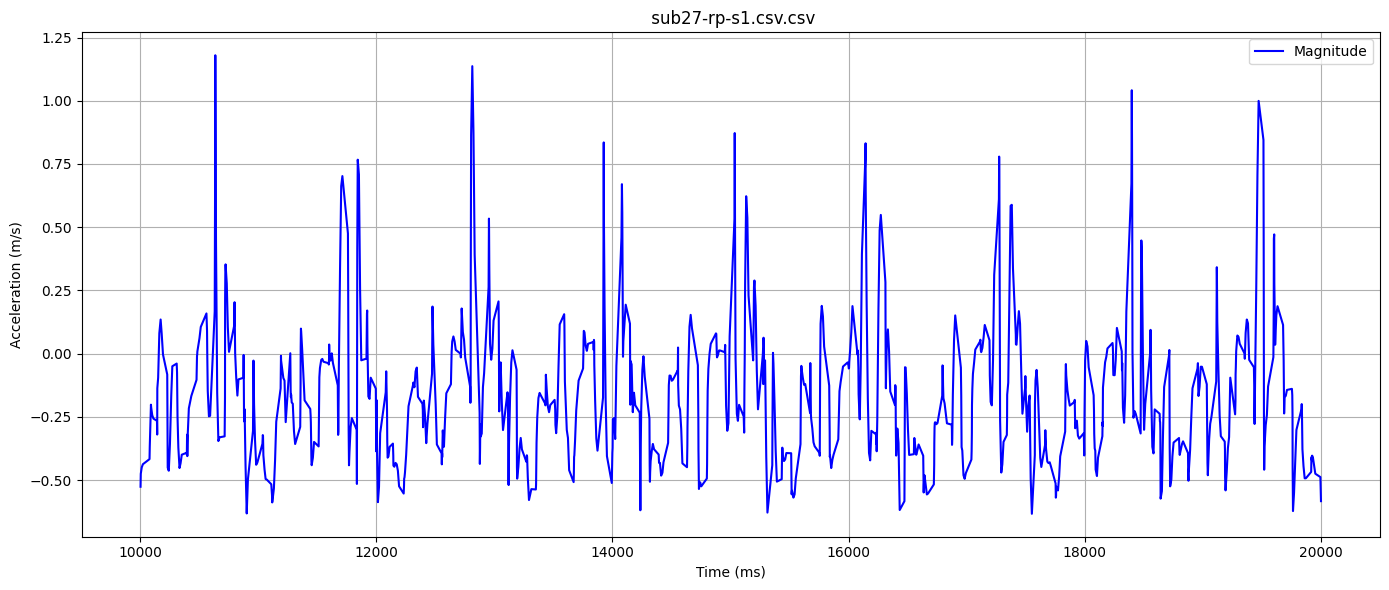

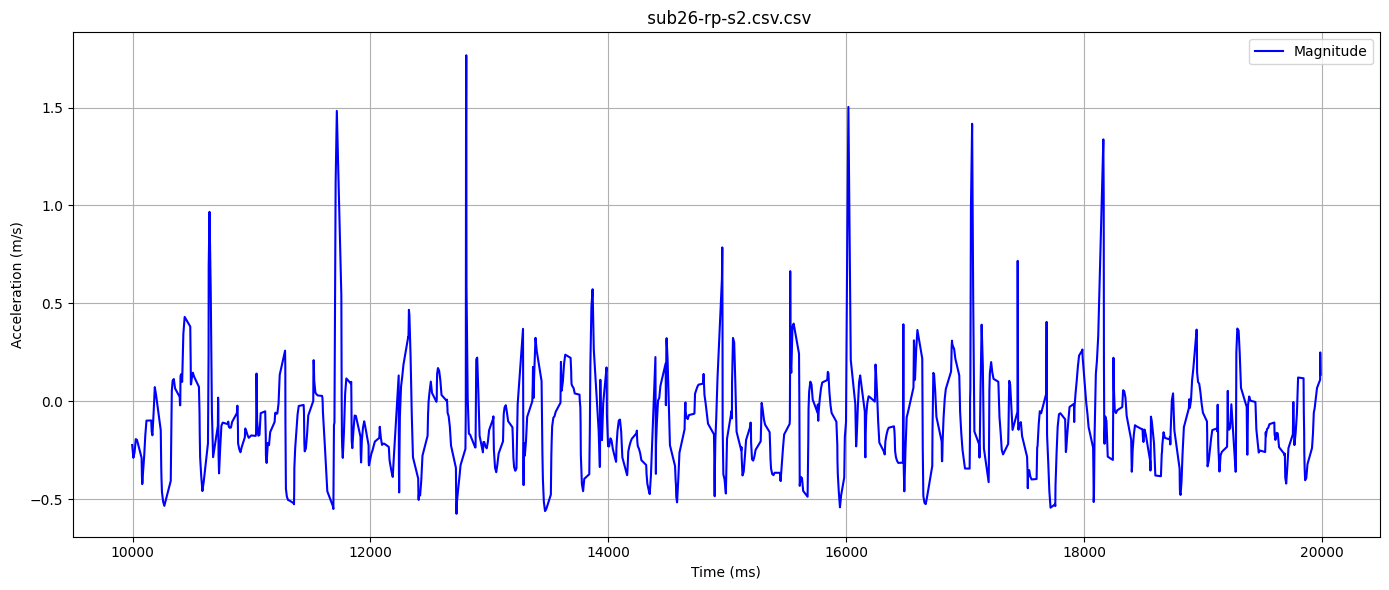

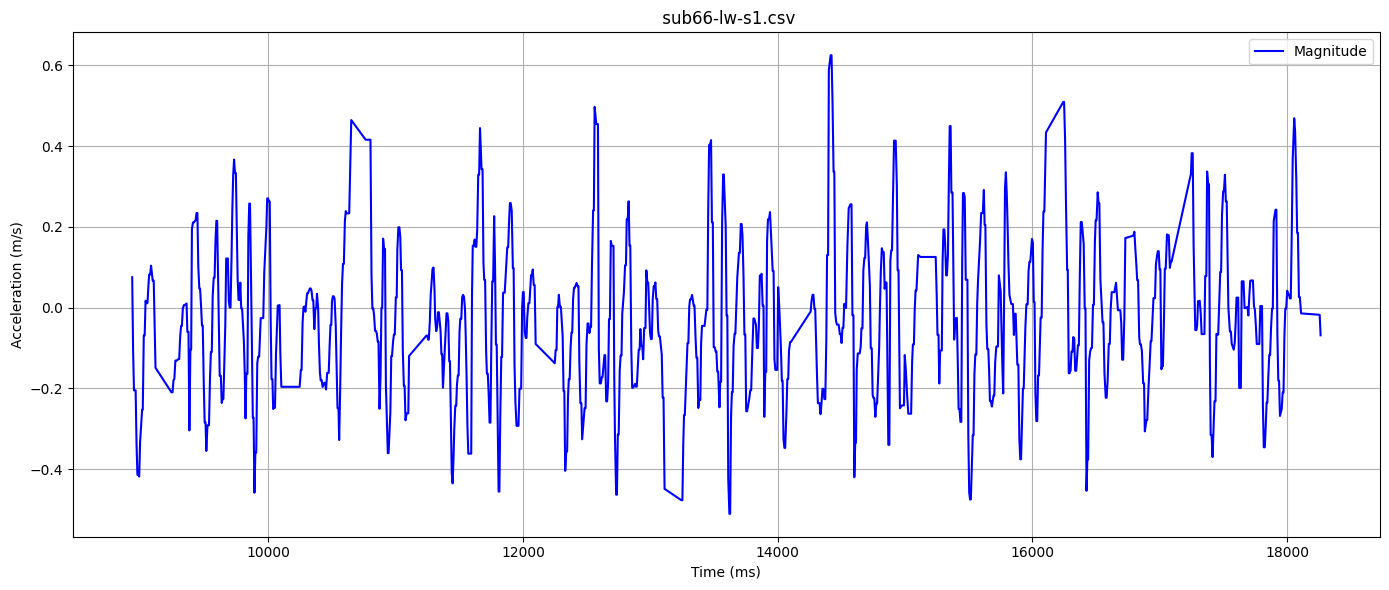

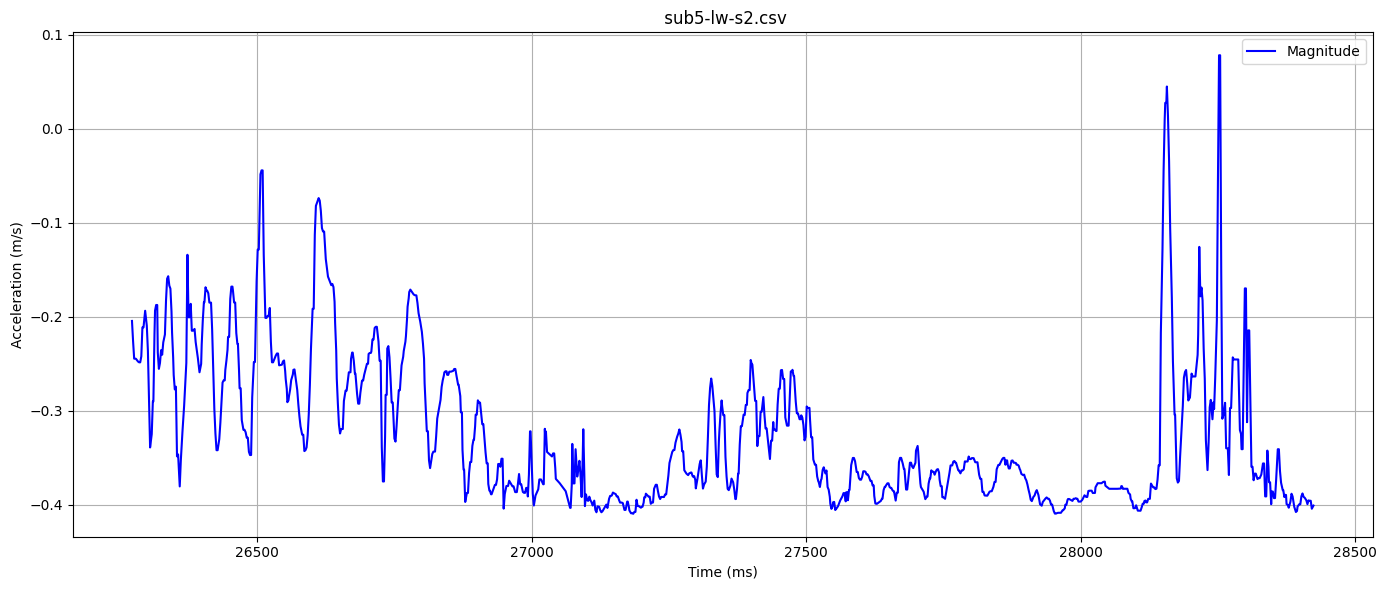

In [21]:
import matplotlib.pyplot as plt 

files_to_print = [f for f in os.listdir(mag_reduced_data_path) if (os.path.isfile(os.path.join(mag_reduced_data_path, f)) and os.path.splitext(os.path.join(mag_reduced_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[:5]


for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(mag_reduced_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'], csv_data['magnitude'], label='Magnitude', color='b')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Next, we apply a Kalman filter on this data to smoothe it out

In [6]:
from filterpy.kalman import KalmanFilter

def create_acc_kalman():
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([[0.], [0.]])
    kf.F = np.array([[1., 1.],
                     [0., 1.]])
    kf.H = np.array([[1., 0.]]) 
    kf.P *= 1000. 
    kf.R = 0.01
    kf.Q = np.array([[5e-5, 0.],
                     [0., 5e-5]])
    
    return kf

def update_kf_F(kf, dt):
    kf.F = np.array([[1., dt],
                     [0., 1.]])


In [ ]:

files_to_update = [f for f in os.listdir(mag_reduced_data_path) if (os.path.isfile(os.path.join(mag_reduced_data_path, f)) and os.path.splitext(os.path.join(mag_reduced_data_path, f))[1] == '.csv')]


kalman_filtered_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data_kalman_filtered'

for filename in files_to_update:
    csv_data = pd.read_csv(os.path.join(mag_reduced_data_path, filename)) 

    kf = create_acc_kalman()

    filtered = []
    for i in range(len(csv_data)):
        # Update the Kalman Filter matrix F
        if i > 0:
            dt = (csv_data['timestamp'].iloc[i] - csv_data['timestamp'].iloc[i-1]) / 1000
            update_kf_F(kf, dt)

        kf.predict()
        kf.update(csv_data['magnitude'].iloc[i])
        filtered.append(kf.x[0][0])

    csv_data['filtered'] = filtered

    csv_data.to_csv(os.path.join(kalman_filtered_data_path, filename), index=False)

In [9]:
import numpy as np 
files_to_update = [f for f in os.listdir(parsed_data_path) if (os.path.isfile(os.path.join(parsed_data_path, f)) and os.path.splitext(os.path.join(parsed_data_path, f))[1] == '.csv')]


kalman_filtered_3_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data_kalman_filtered_3'

for filename in files_to_update:
    csv_data = pd.read_csv(os.path.join(parsed_data_path, filename)) 

    # Create separate filters for each axis
    kf_x = create_acc_kalman()
    kf_y = create_acc_kalman()
    kf_z = create_acc_kalman()

    filtered_x, filtered_y, filtered_z = [], [], []

    for i in range(len(csv_data)):
        if i > 0:
            dt = (csv_data['timestamp'].iloc[i] - csv_data['timestamp'].iloc[i - 1]) / 1000.0
            update_kf_F(kf_x, dt)
            update_kf_F(kf_y, dt)
            update_kf_F(kf_z, dt)

        # Predict and update each axis separately
        kf_x.predict()
        kf_x.update(csv_data['acc_x'].iloc[i])
        filtered_x.append(kf_x.x[0][0])

        kf_y.predict()
        kf_y.update(csv_data['acc_y'].iloc[i])
        filtered_y.append(kf_y.x[0][0])

        kf_z.predict()
        kf_z.update(csv_data['acc_z'].iloc[i])
        filtered_z.append(kf_z.x[0][0])

    # Add the new filtered columns to the DataFrame
    csv_data['acc_x_kf'] = filtered_x
    csv_data['acc_y_kf'] = filtered_y
    csv_data['acc_z_kf'] = filtered_z

    csv_data.to_csv(os.path.join(kalman_filtered_3_data_path, filename), index=False)

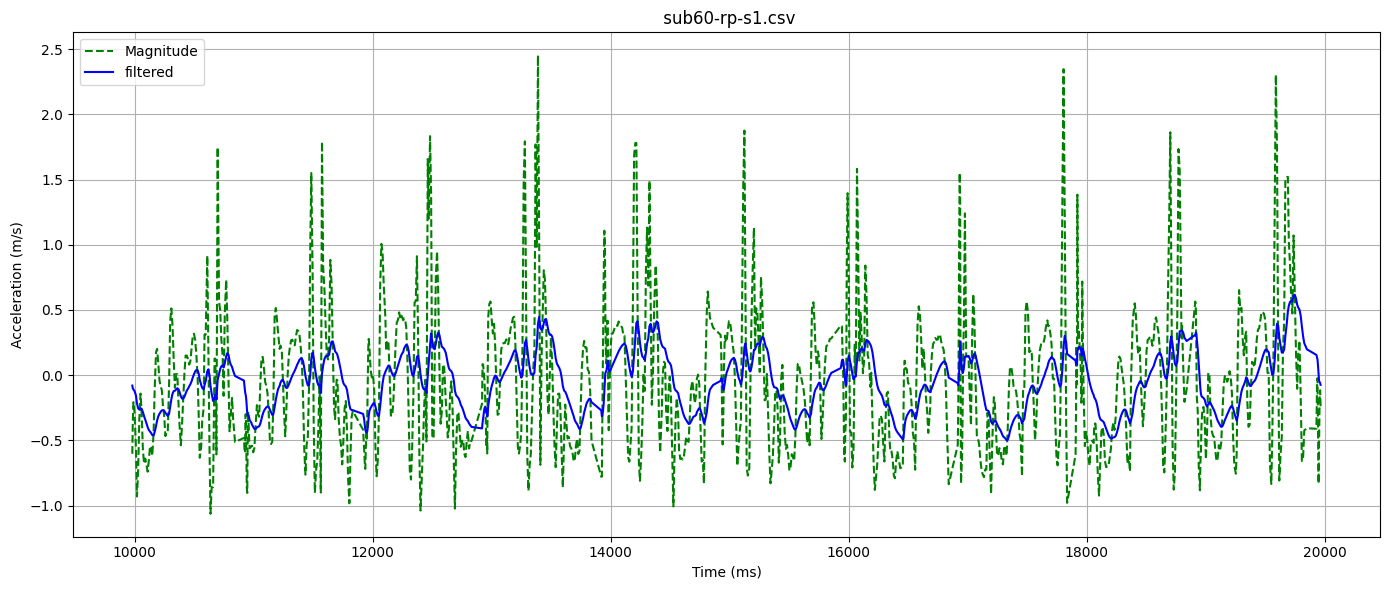

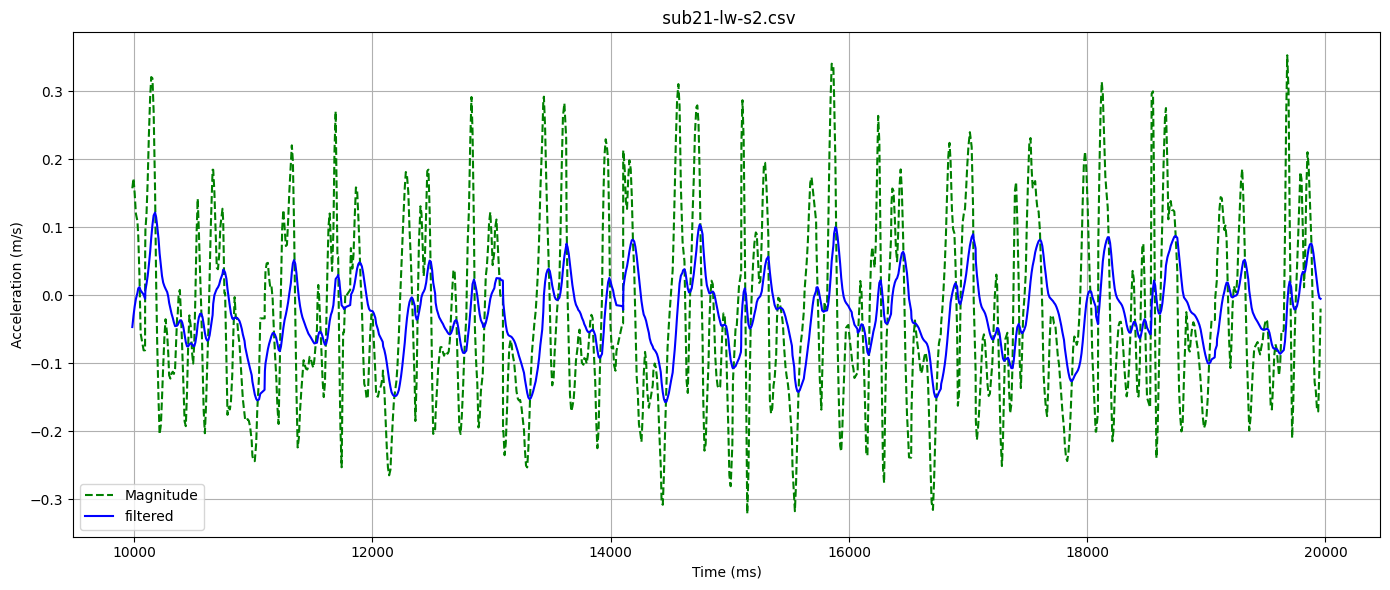

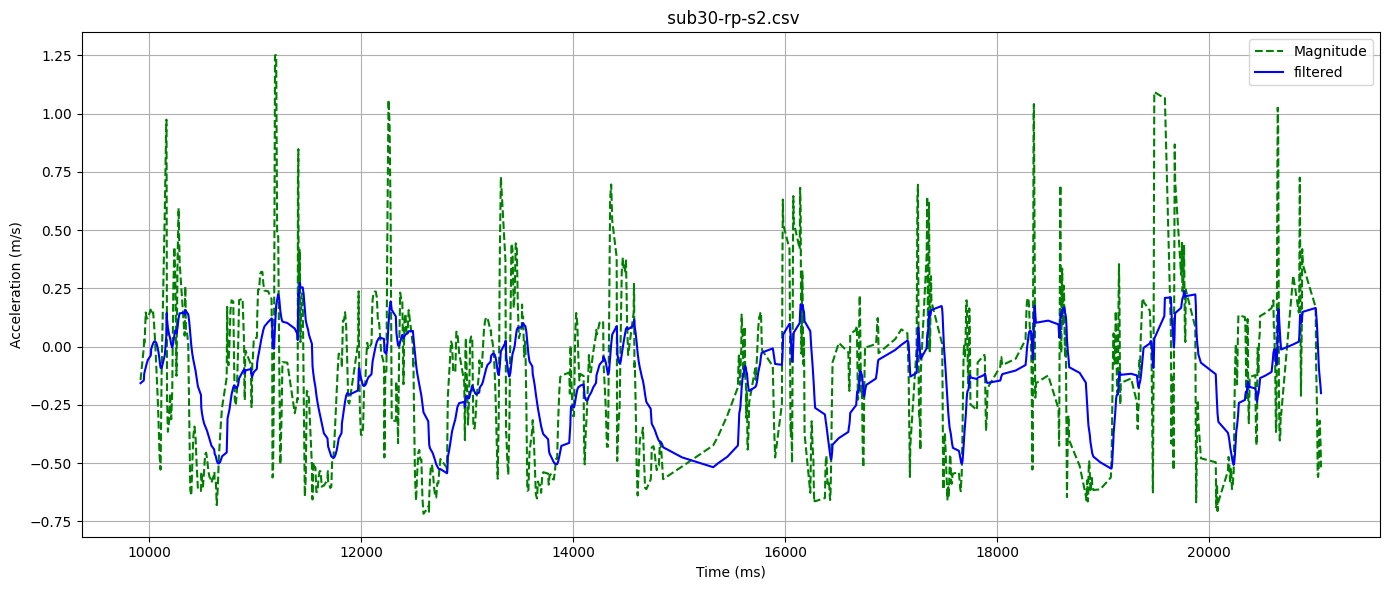

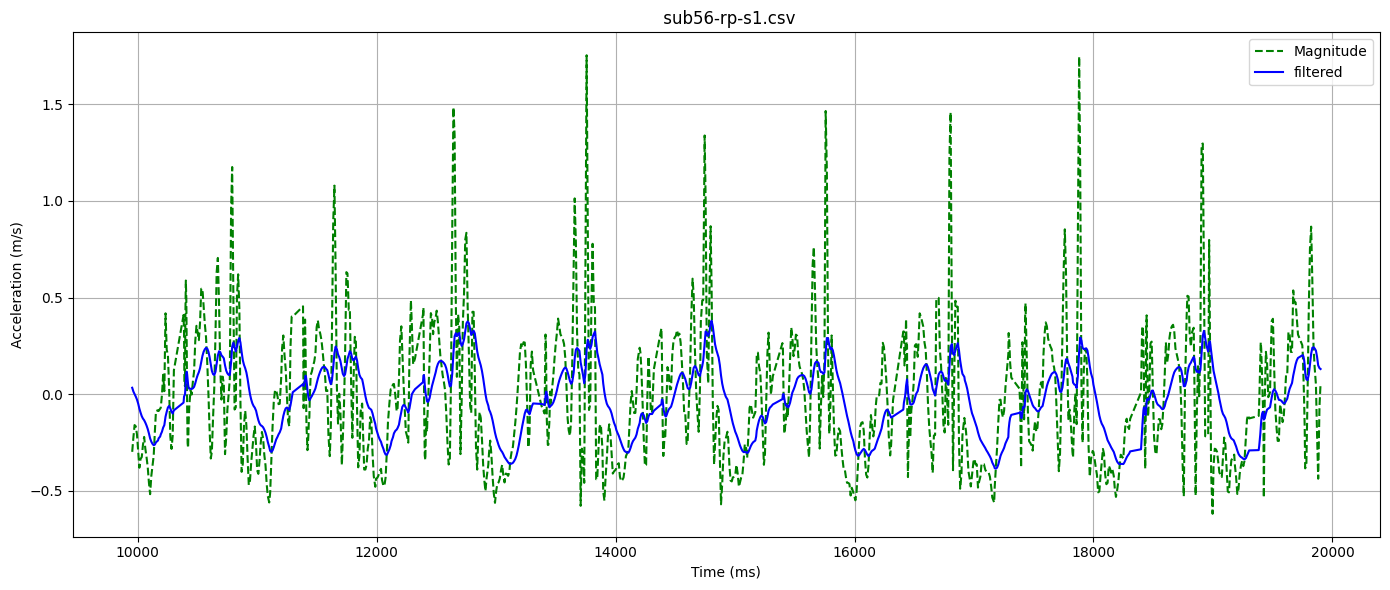

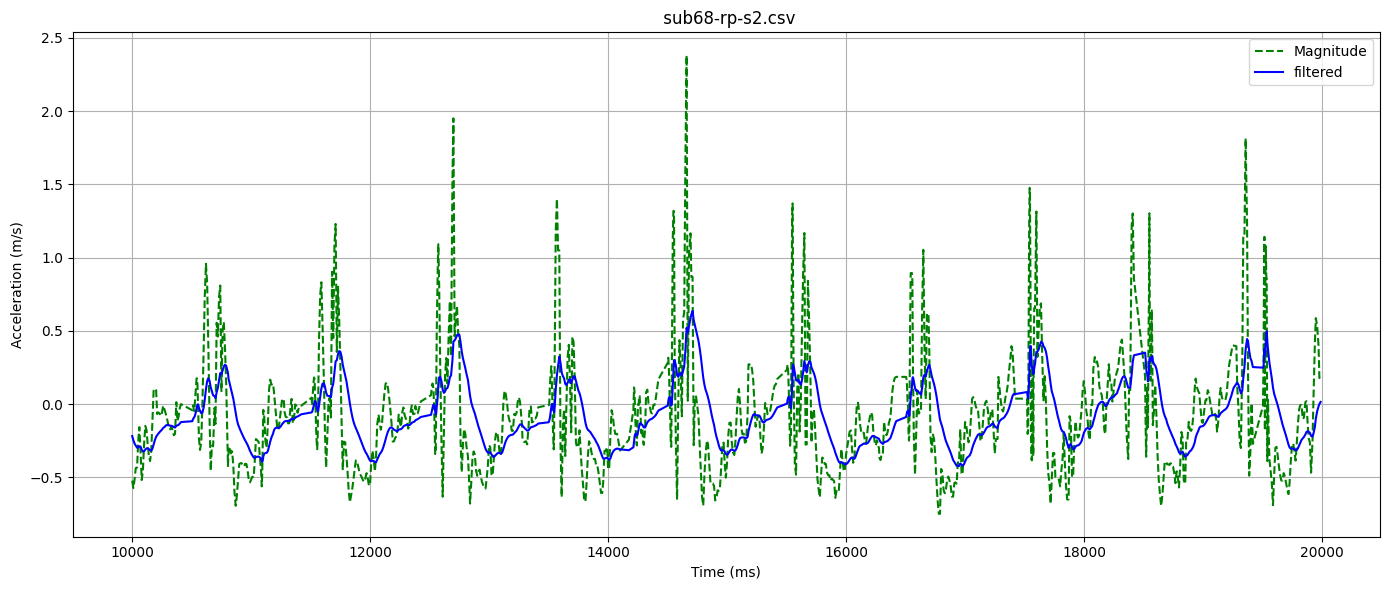

In [18]:
import matplotlib.pyplot as plt 

files_to_print = [f for f in os.listdir(kalman_filtered_data_path) if (os.path.isfile(os.path.join(kalman_filtered_data_path, f)) and os.path.splitext(os.path.join(kalman_filtered_data_path, f))[1] == '.csv')]
files_to_print = files_to_print[:5]


for filename in files_to_print:
    csv_data = pd.read_csv(os.path.join(kalman_filtered_data_path, filename)) 

    csv_data = csv_data[1000:2000]

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'], csv_data['magnitude'], label='Magnitude', color='g', linestyle='--')
    plt.plot(csv_data['timestamp'], csv_data['filtered'], label='filtered', color='b')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Implement the step detection algorithm presented in the paper

In [11]:
def detect_steps(df, mag_col='filtered', time_col='timestamp', threshold=0.2, min_gap_ms = 200):

    mag = df[mag_col].values
    time = df[time_col].values

    peak_vector = []
    in_peak = False
    last_step_time = None

    df['peak'] = 0

    for i in range(len(mag)):
        c = mag[i]
        

        # If we’re above the threshold, add to peak vector
        if c > threshold:
            peak_vector.append({'mag': c, 'idx': i})
            in_peak = True
        elif in_peak:  # we just exited a peak
            if peak_vector:
                max_item = max(peak_vector, key=lambda item: item['mag']) 

                step_time = time[max_item['idx']]

                df.at[max_item['idx'], 'peak'] = 1
                # Apply temporal constraint
               # if last_step_time is None or (step_time - last_step_time) >= min_gap_ms:
                    # df.at[max_item['idx'], 'peak'] = 1
                    #last_step_time = step_time

            # Reset for next peak
            peak_vector = []
            in_peak = False

    return df
    


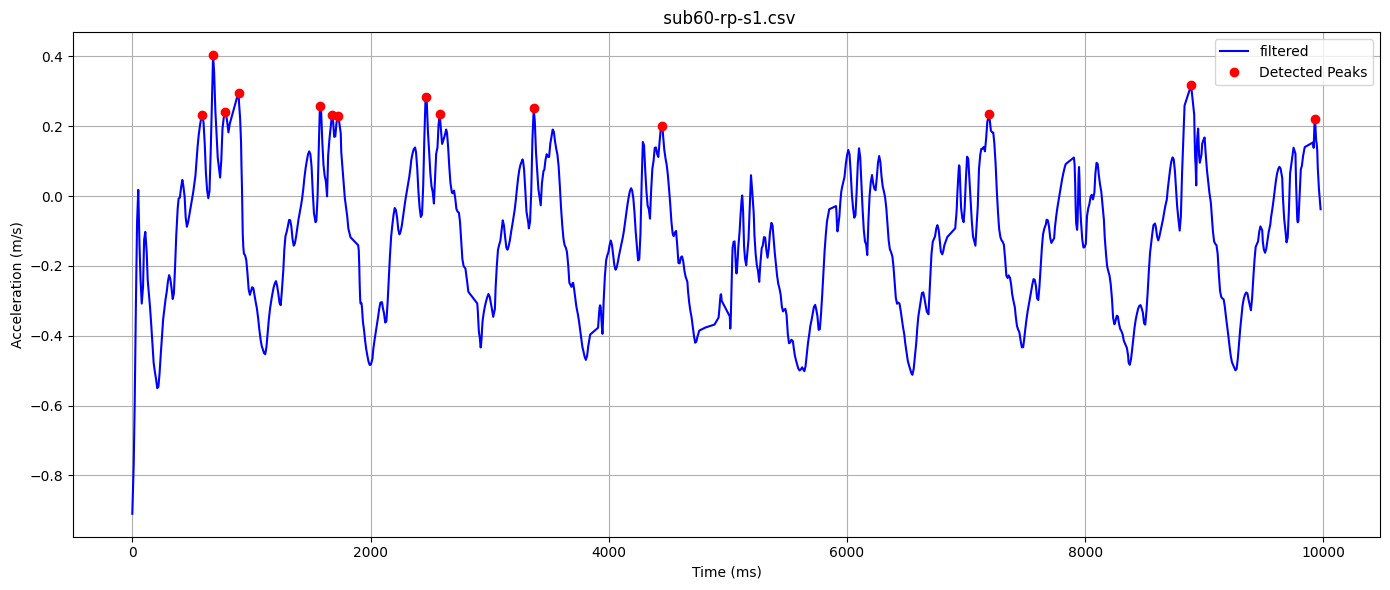

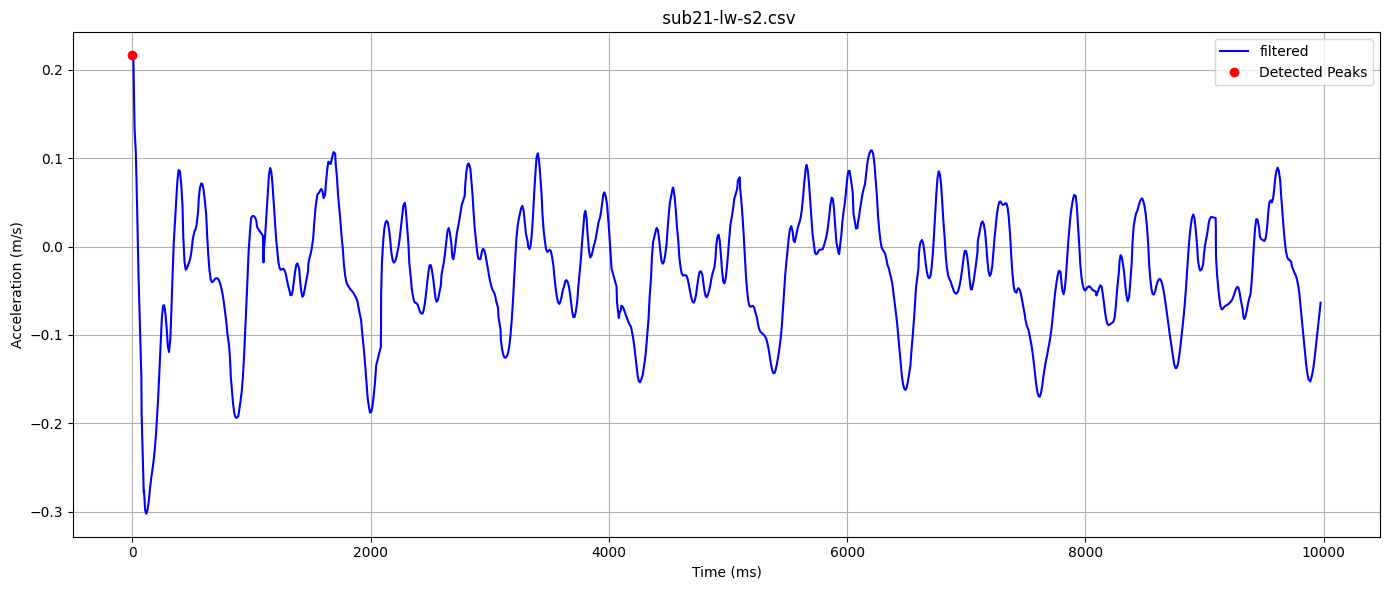

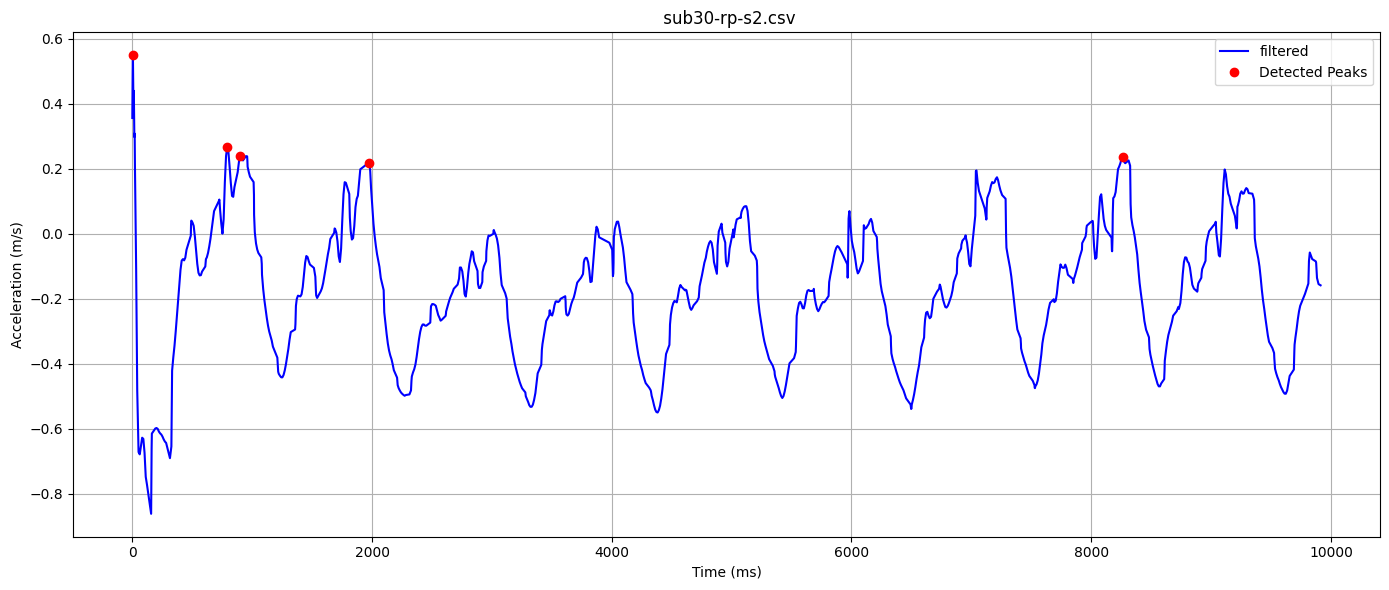

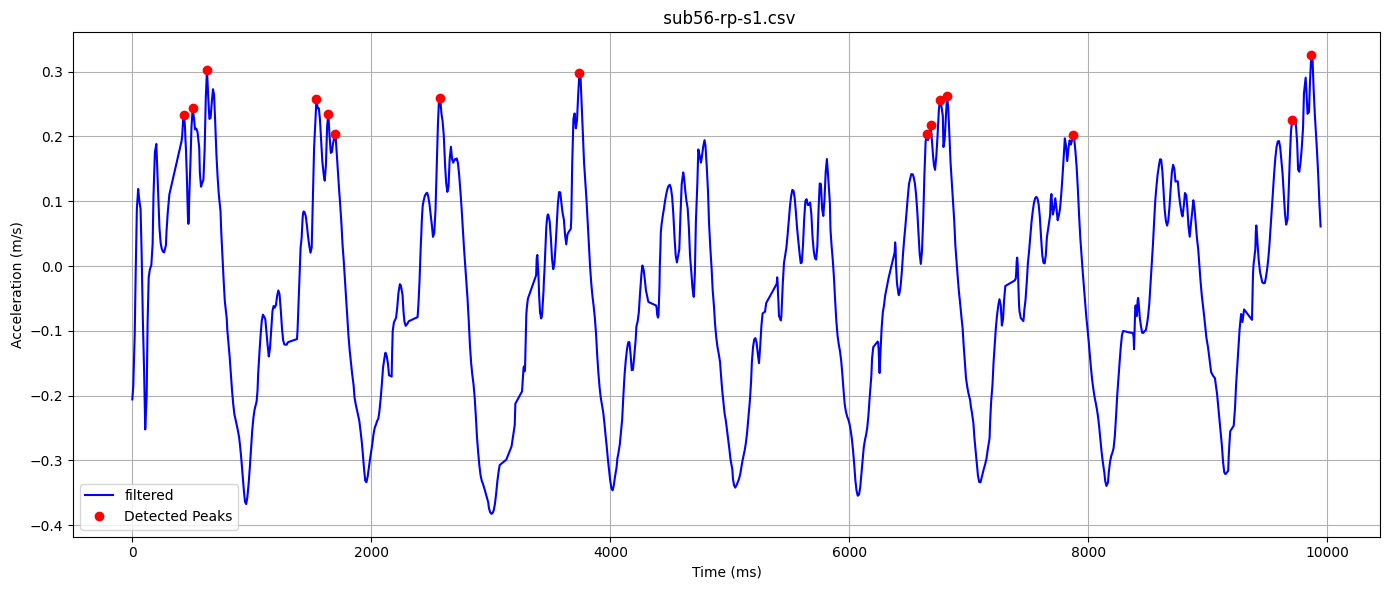

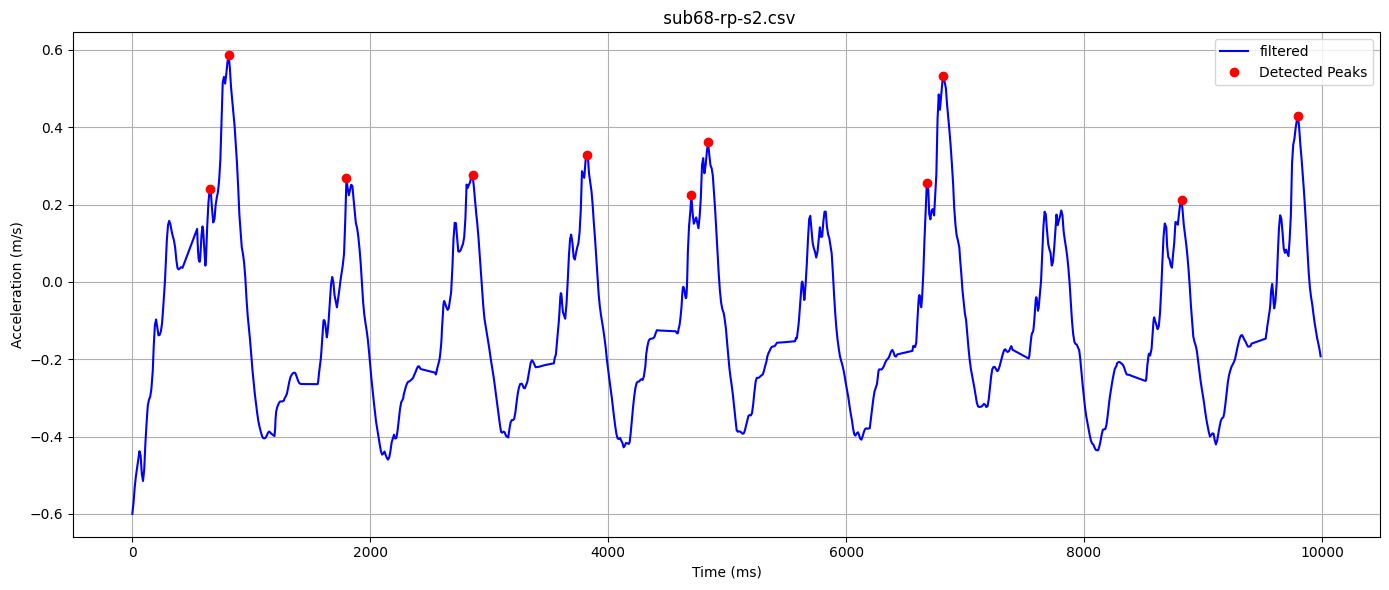

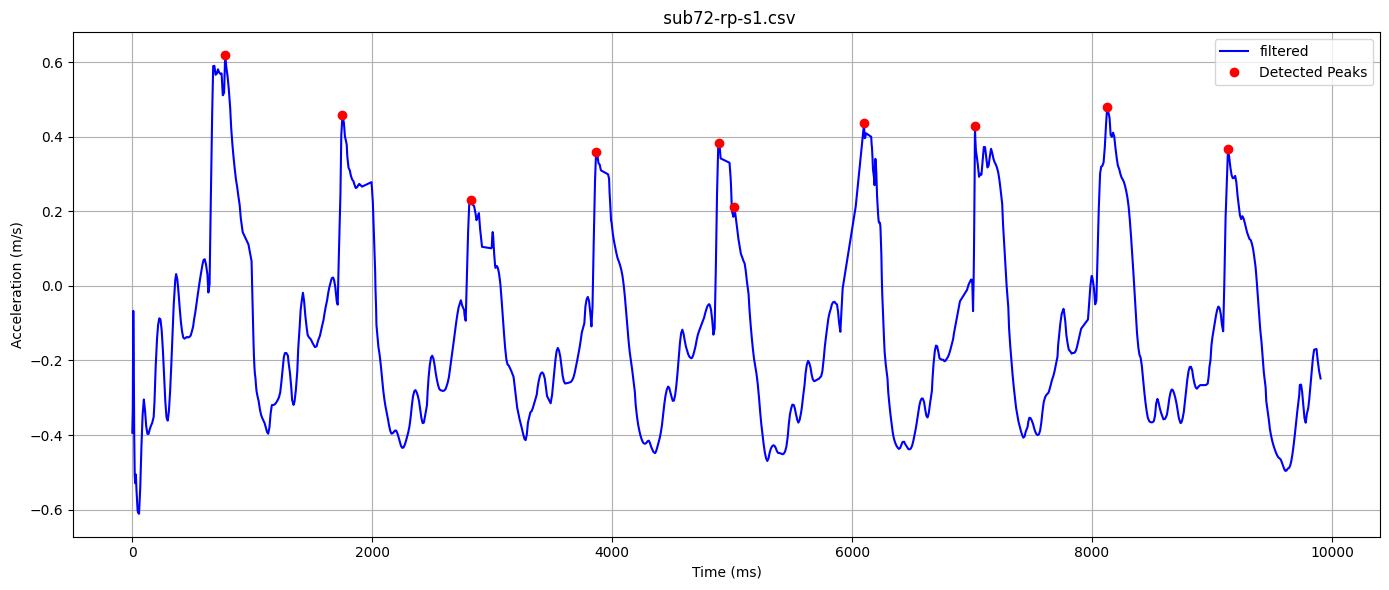

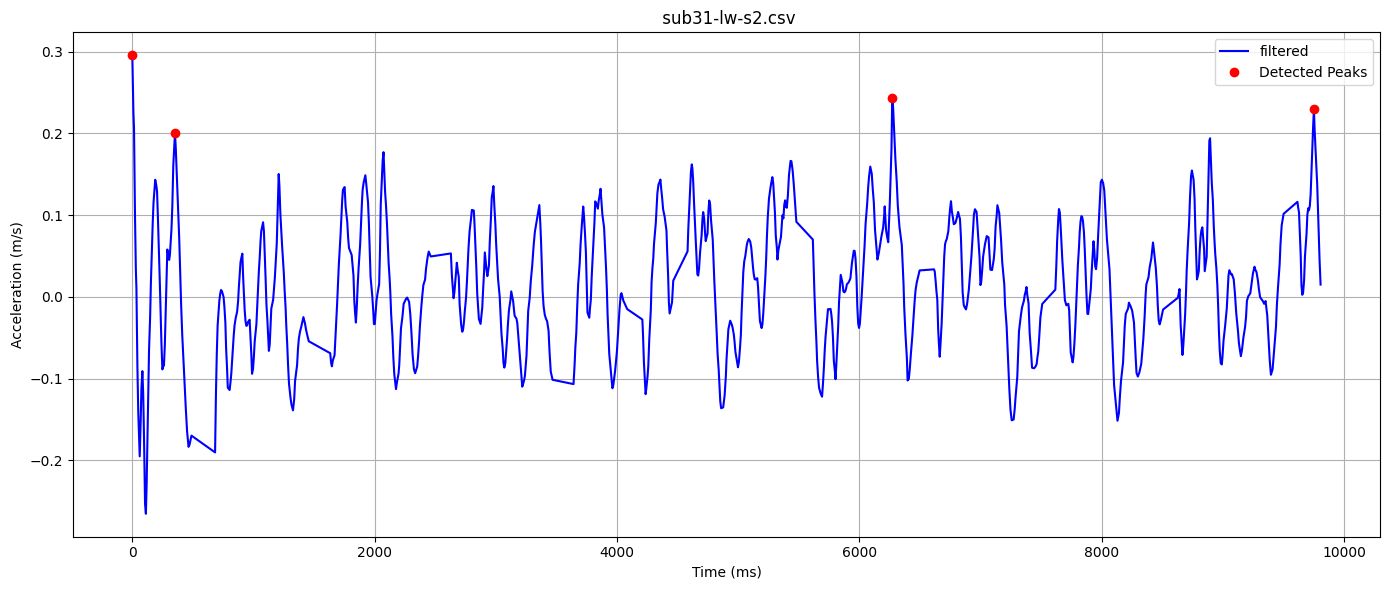

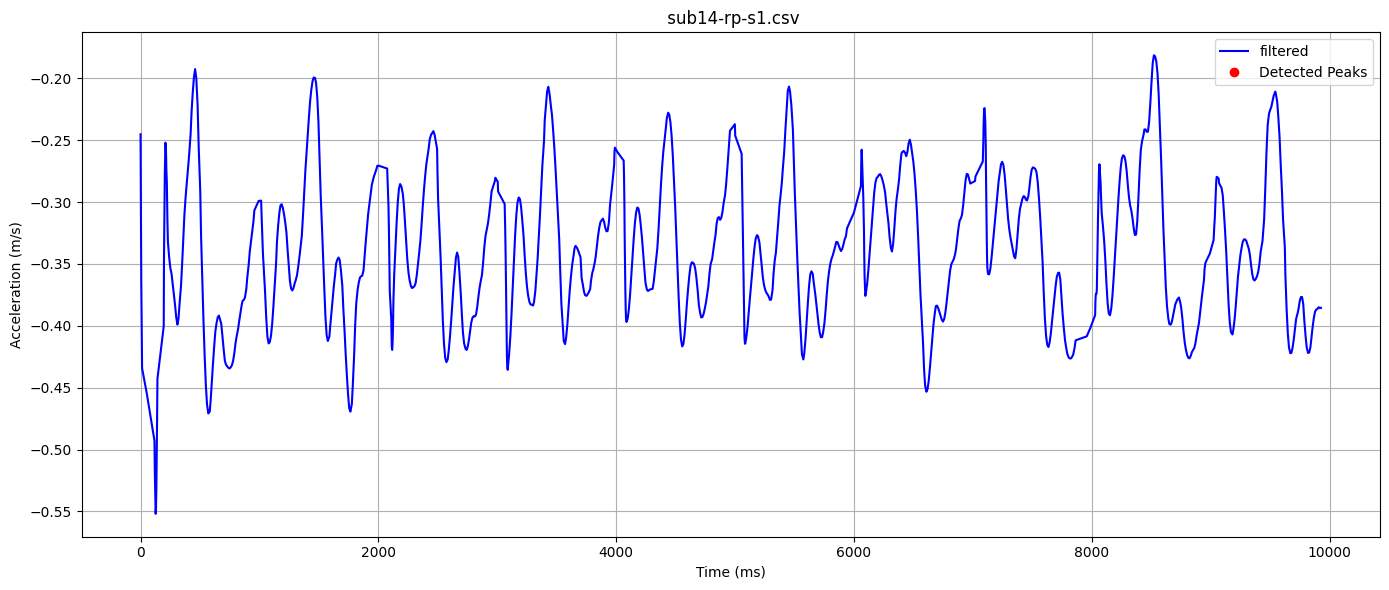

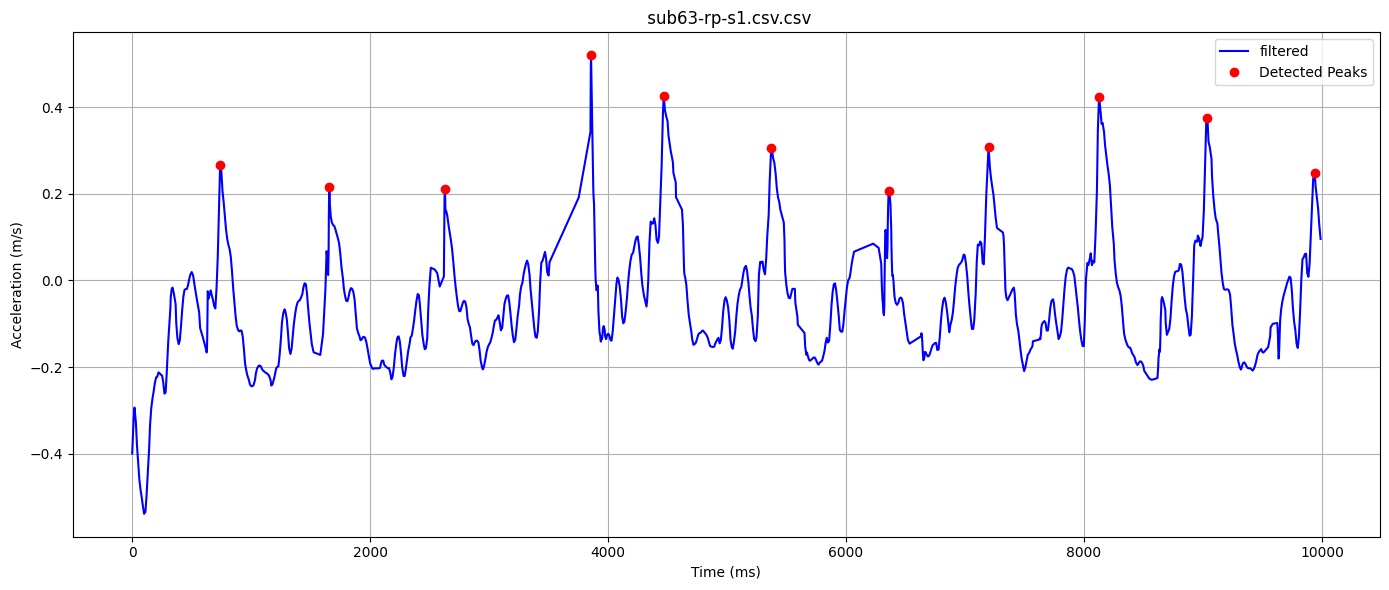

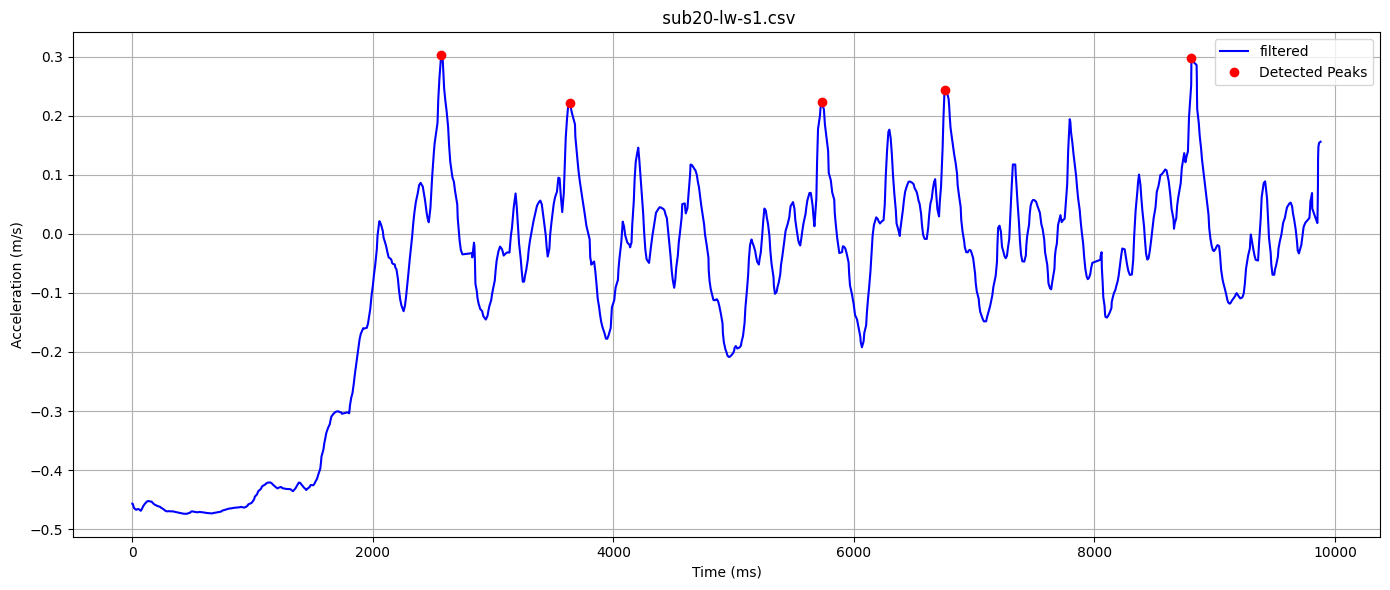

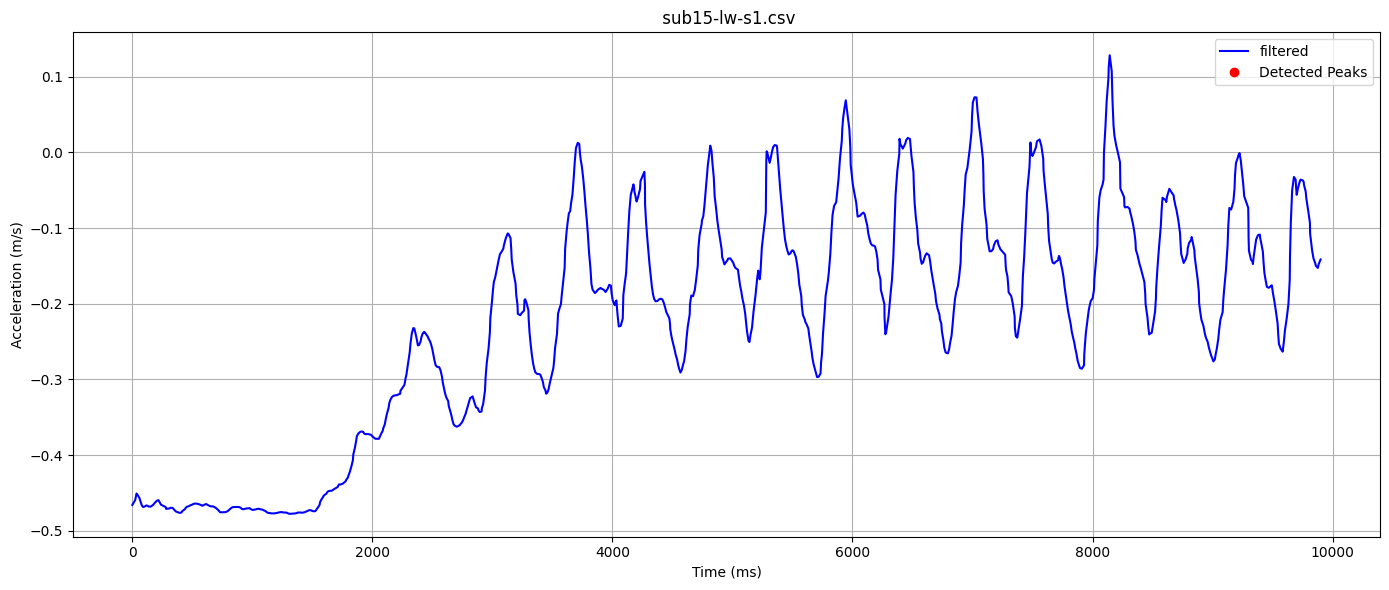

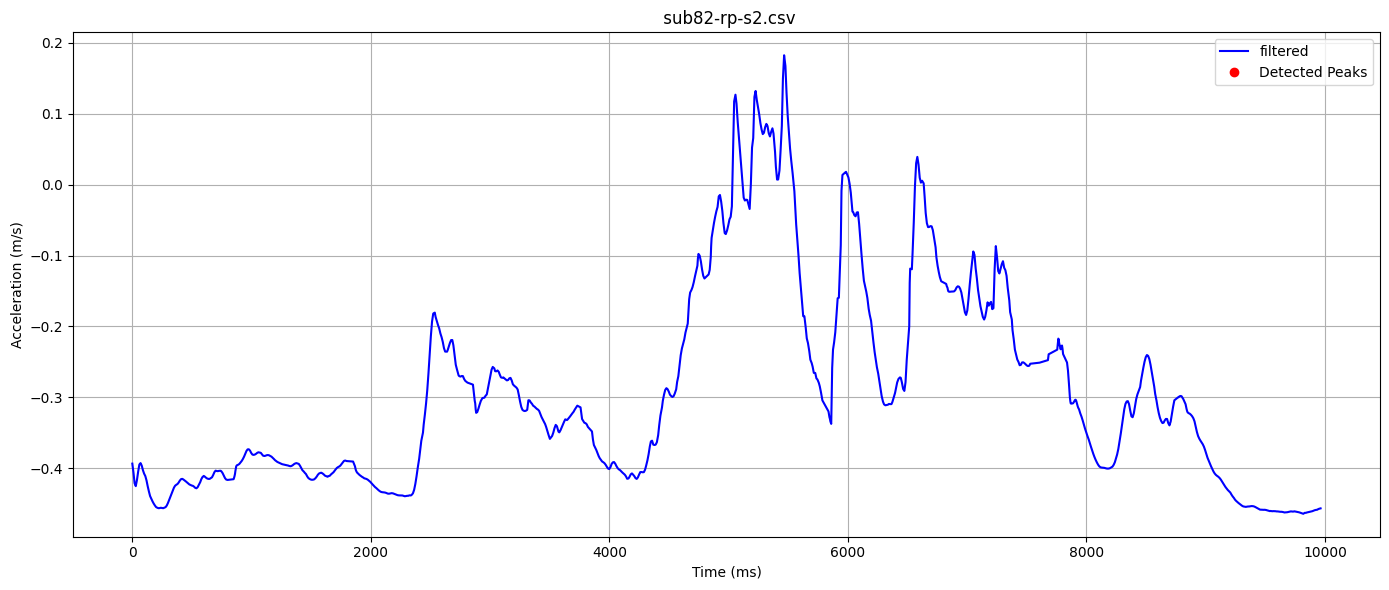

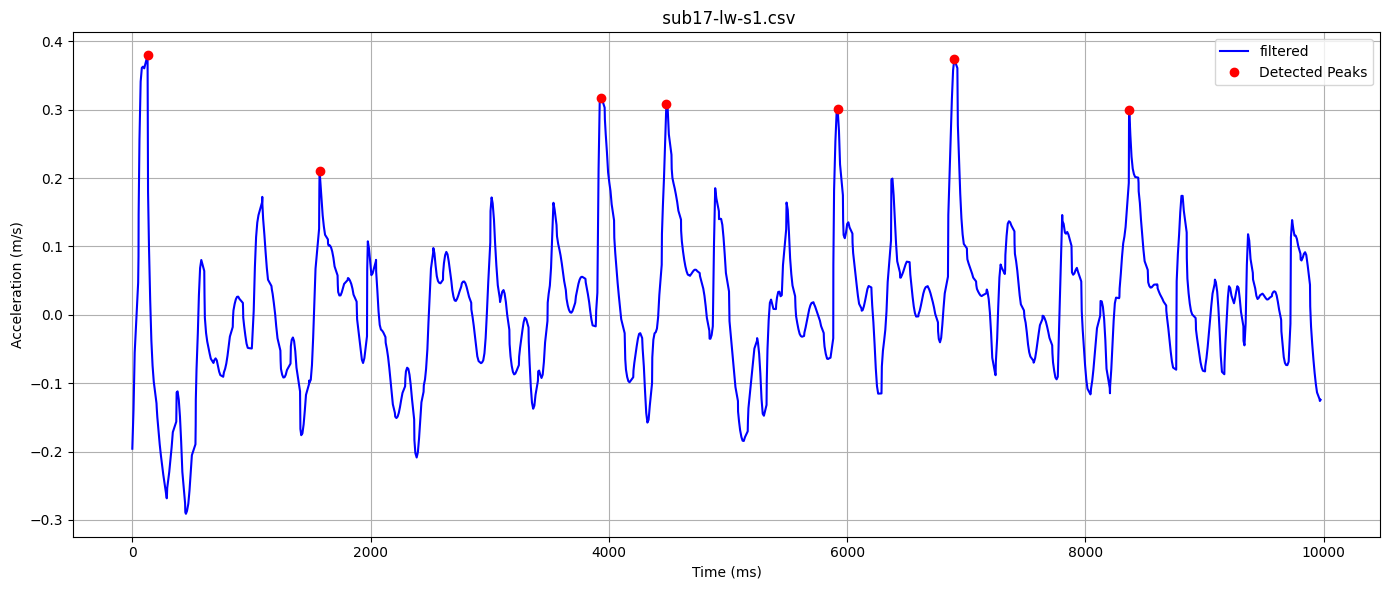

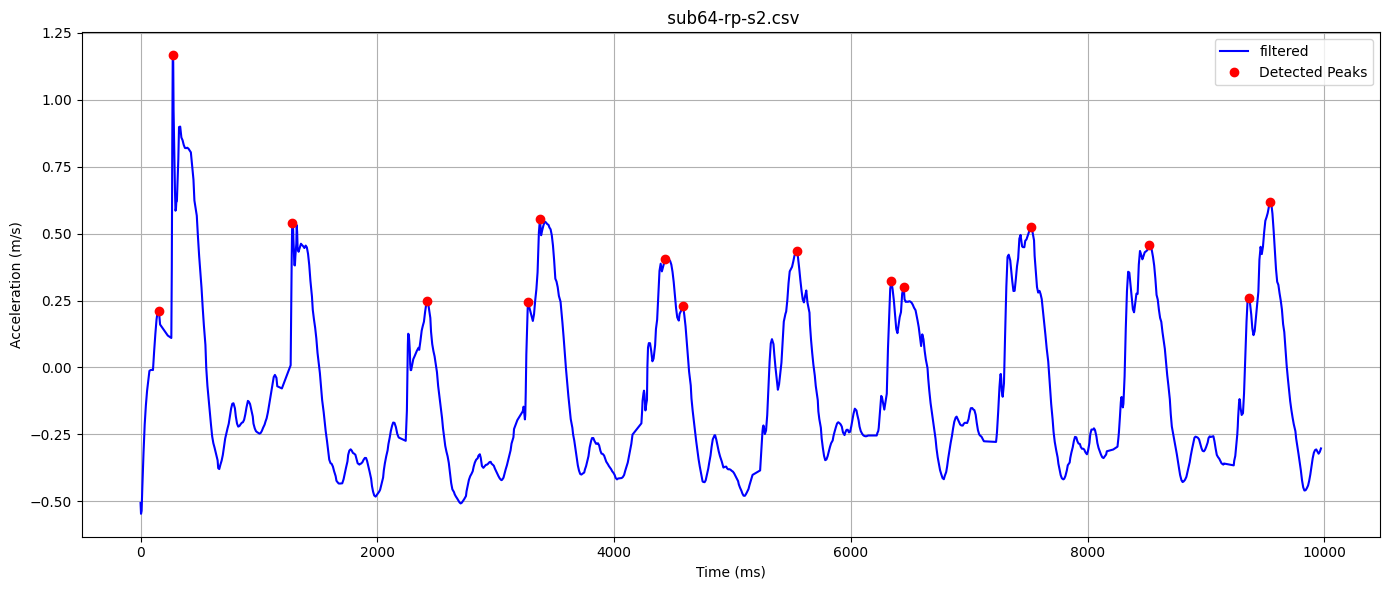

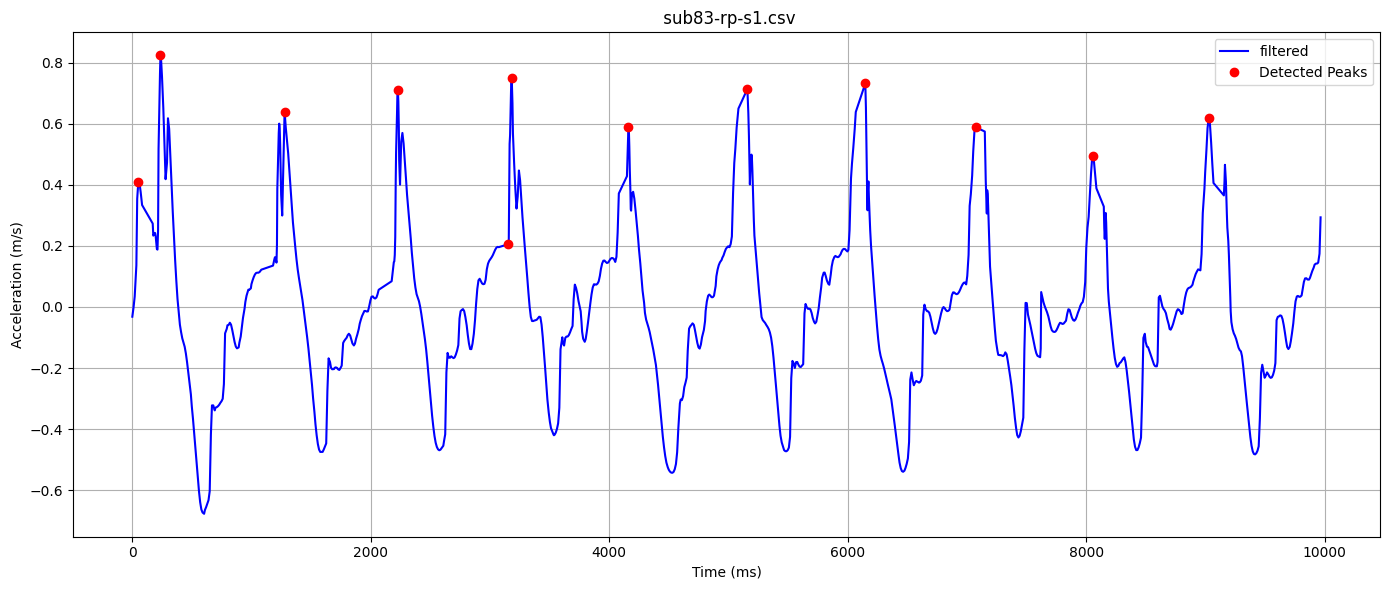

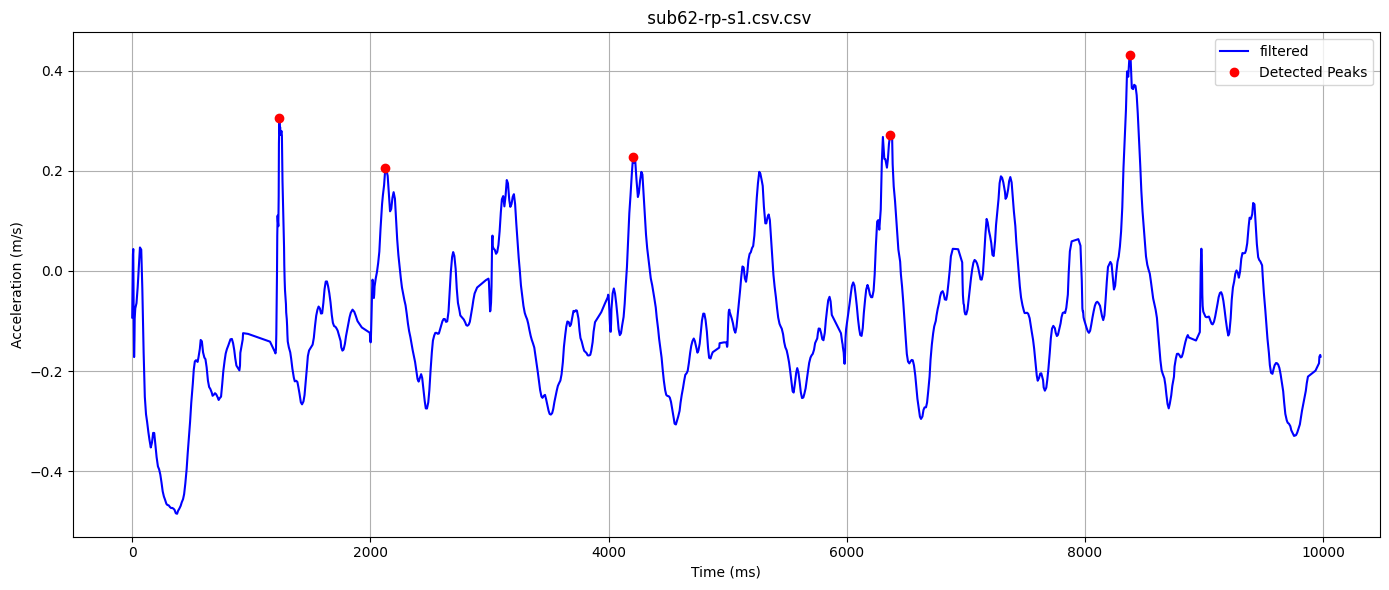

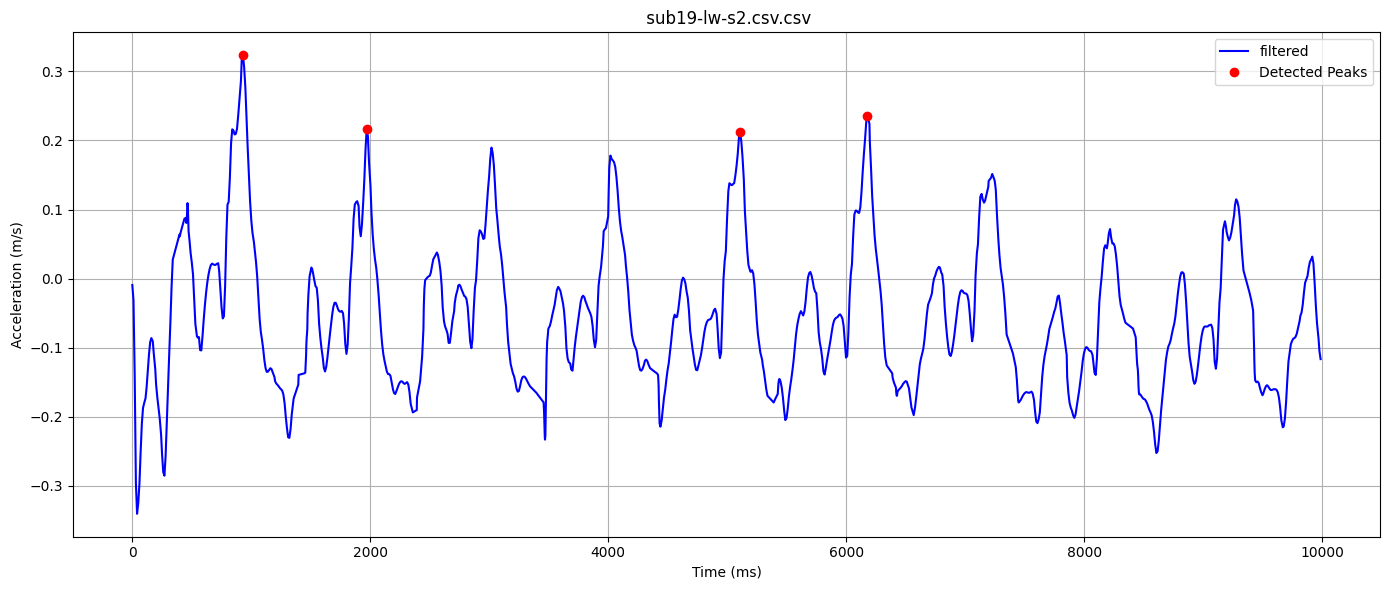

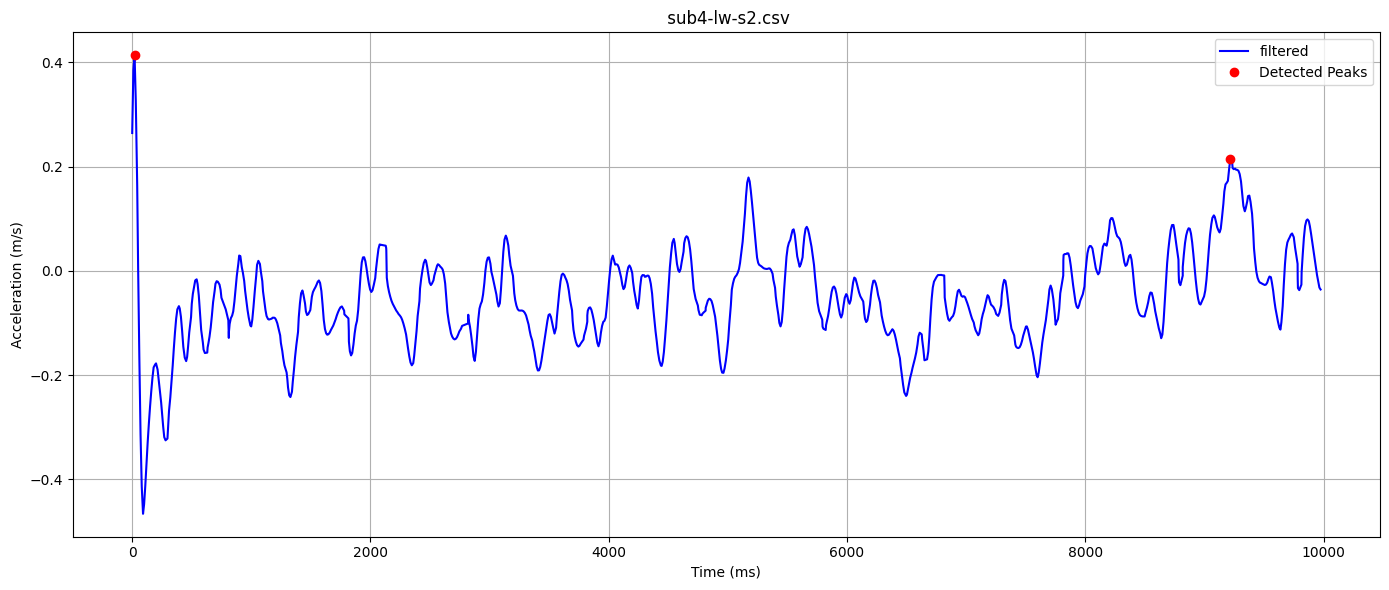

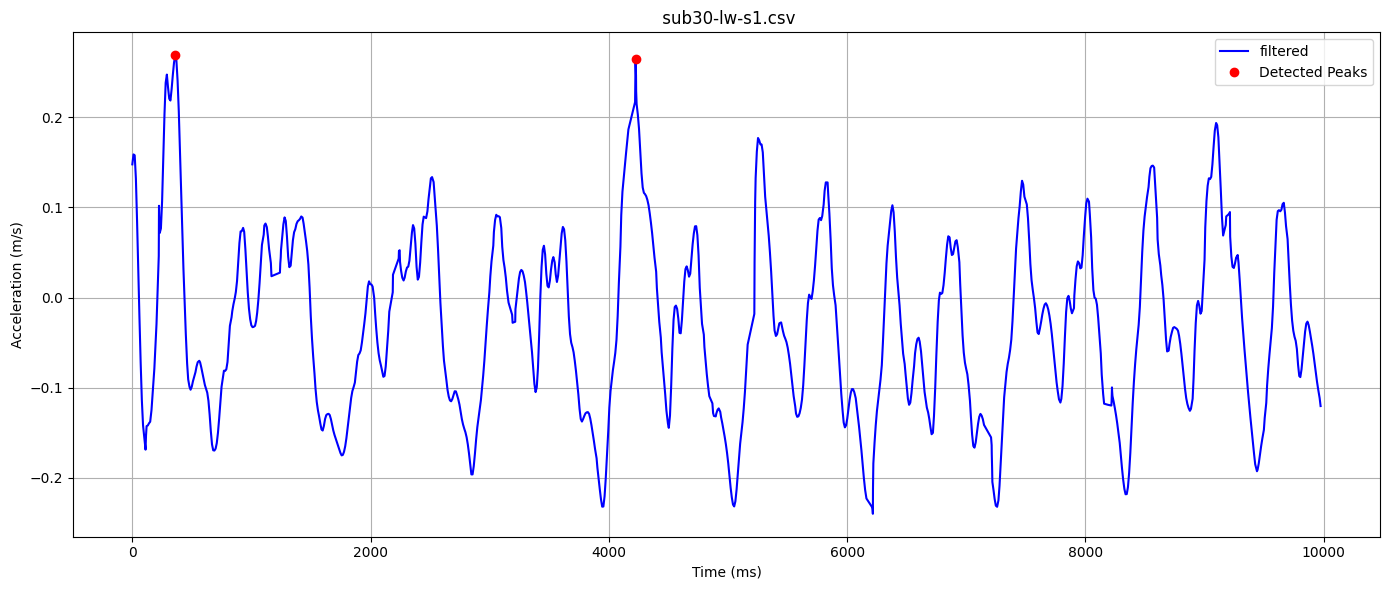

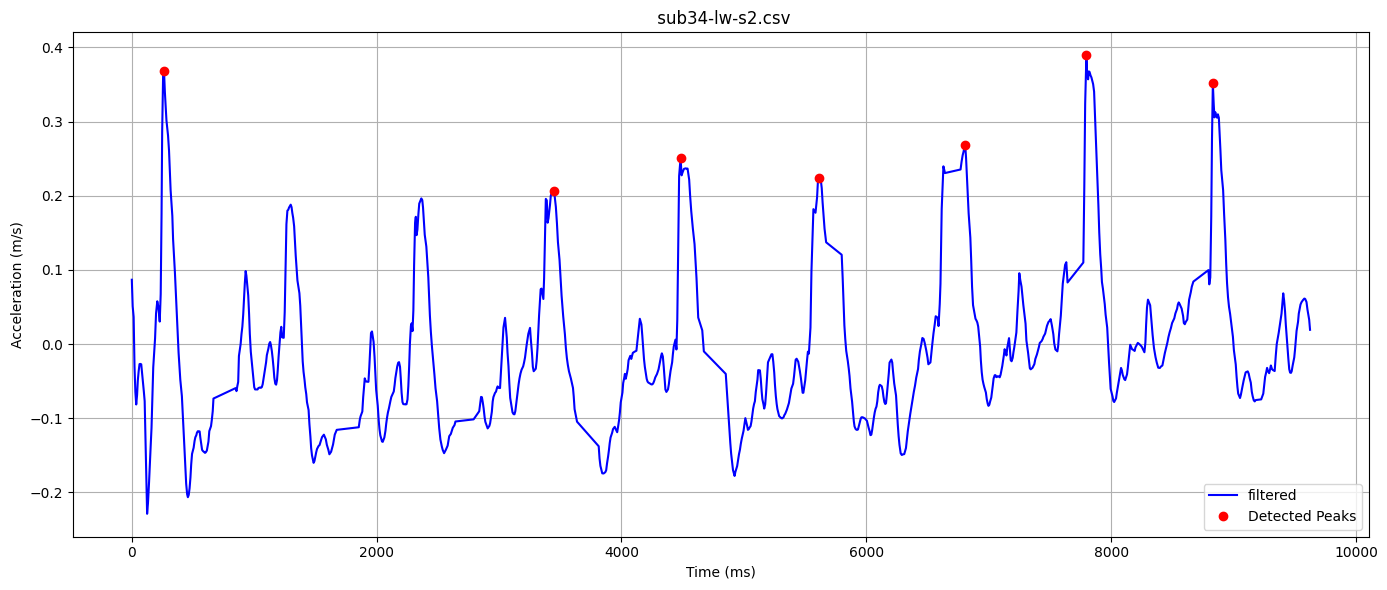

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

kalman_filtered_data_path = '../data/kaggle-drdataboston/attempt_3/updated_data_kalman_filtered'

files_to_update = [f for f in os.listdir(kalman_filtered_data_path) if (os.path.isfile(os.path.join(kalman_filtered_data_path, f)) and os.path.splitext(os.path.join(kalman_filtered_data_path, f))[1] == '.csv')]

files_to_update = files_to_update[5:25]


for filename in files_to_update:
    csv_data = pd.read_csv(os.path.join(kalman_filtered_data_path, filename)) 



    csv_data = detect_steps(csv_data)

    plt.figure(figsize=(14,6))

    plt.plot(csv_data['timestamp'][:1000], csv_data['filtered'][:1000], label='filtered', color='b')

    csv_data_peaks = csv_data[:1000]
    peaks = csv_data_peaks[csv_data_peaks['peak'] == 1]

    plt.plot(peaks['timestamp'], peaks['filtered'], 'o', color='r', label='Detected Peaks')

    plt.title(filename)
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration (m/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()